In [1]:
import pandas as pd
import sys
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

## Make exported plots' text seen as text in Illustrator
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

sns.set_theme(style="white")

In [2]:
input_csv_dir = r"C:/data/ER-interpolation-Ecad-acat-NEW/Results/IntensityMeasurements"
output_csv_dir = r"C:\data\ER-interpolation-Ecad-acat-NEW\005-plots"

output_csv_dir_exists = os.path.exists(output_csv_dir)

if not output_csv_dir_exists:
    os.makedirs(output_csv_dir)

In [3]:
pal = sns.color_palette("colorblind")
pal

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [4]:
print(pal.as_hex())

#palette = {"EPcadKO+ER-StayGold"                     : "#d55e00",
#          "EPcadKO+ER-StayGold+Ecad-WT-RFP"          : "#029e73",
#          "acatKO+ER-StayGold"                       : "#cc78bc",
#           "EPcadKO+ER-StayGold+Ecad-acat-RFP"        : "#56b4e9",
#           "EPcadKO+ER-StayGold+Ecad-acat-vinc-m-RFP" : "#0173b2",
#          }

palette = {"E/PcadKO"                  : "#d55e00",
           "E/PcadKO+Ecad-WT"          : "#029e73",
           "acatKO"                   : "#cc78bc",
           "E/PcadKO+Ecad-acat"        : "#56b4e9",
           "E/PcadKO+Ecad-acat-vinc-m" : "#0173b2",
          }


['#0173b2', '#de8f05', '#029e73', '#d55e00', '#cc78bc', '#ca9161', '#fbafe4', '#949494', '#ece133', '#56b4e9']


In [5]:
def ProcessDF(df):
    
    # Example filename: EPcadKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_C1_Intensity.csv
    
    # Split file name at .tif, one before and one after the .tif_
    # 'split1' = file name before '.tif_'
    # 'split2' = file name after '.tif_'
    df[["split1", "split2"]] = df["Label"].str.split(".tif_", expand = True)
    
    #Split the first split file name at "_cell-" and assign it as 'cell' for the cell line name
    #split3 is the cell line name from the beginning to '_cell-'
    df[["split3", "cell"]] = df["split1"][0].split("_cell-")
    
    #Label 'channel' to the channel number in the 'split2'
    df["channel"] = df["split2"].str.slice(start = 1, stop=2)
    
    #Assign channel name to each channel number
    df.loc[df["channel"] == "1", "channel_name"] = "ER"
    df.loc[df["channel"] == "2", "channel_name"] = "WGA"
    df.loc[df["channel"] == "3", "channel_name"] = "Ecad"
    
    #Create a df named 'cell_line' name in split3 from beginning to right before image name '_###'
    #You can later replace the cell line with the channel name with just the cell line (see below)
    df["cell_line"] = df["split3"].str.slice(start = 0, stop = -7)
    
    #Assign image name to split3 (the file name from beginning to _cell-)
    df["image"] = df["split3"].str.slice(start=-6, stop=-3)
    
    #Assign replicate number in split3
    df["Rep"] = df["split3"].str.slice(start=-1)
    df.drop(columns = ["split1", "split2", "split3"], inplace = True)
    
    
    return df

input_CSVs = os.listdir(input_csv_dir)

df_concat = pd.DataFrame()

for f in input_CSVs:
    f_path = os.path.join(input_csv_dir, f)
    df_temp = pd.read_csv(f_path, usecols = ["Label", "Area", "Mean", "IntDen", "RawIntDen", "Slice"])
    df_temp["Label"] = f
    df_processed = ProcessDF(df_temp)
    df_concat = pd.concat([df_concat, df_processed])

In [6]:
df = df_concat
df

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
0,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,100.133,338.752,33920.080,8028421.0,1,001,1,ER,acatKO+ER-StayGold_ER+WGA,001,1
1,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,7.275,366.329,2665.210,630819.0,2,001,1,ER,acatKO+ER-StayGold_ER+WGA,001,1
2,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,6.460,364.398,2354.018,557164.0,3,001,1,ER,acatKO+ER-StayGold_ER+WGA,001,1
3,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,6.557,363.471,2383.352,564107.0,4,001,1,ER,acatKO+ER-StayGold_ER+WGA,001,1
4,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,6.975,356.142,2484.262,587991.0,5,001,1,ER,acatKO+ER-StayGold_ER+WGA,001,1
...,...,...,...,...,...,...,...,...,...,...,...,...
19,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,42.537,17.375,739.100,174935.0,20,005,2,WGA,EPcadKO+ER-StayGold_ER+WGA,010,1
20,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,44.553,17.725,789.712,186914.0,21,005,2,WGA,EPcadKO+ER-StayGold_ER+WGA,010,1
21,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,46.745,18.054,843.961,199754.0,22,005,2,WGA,EPcadKO+ER-StayGold_ER+WGA,010,1
22,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,49.627,18.334,909.871,215354.0,23,005,2,WGA,EPcadKO+ER-StayGold_ER+WGA,010,1


In [7]:
df["cell_line"].unique()

array(['acatKO+ER-StayGold_ER+WGA',
       'EPcadKO+ER-StayGold+Ecad-RFP-acat-vinc-m_ER+WGA+Ecad',
       'EPcadKO+ER-StayGold+Ecad-RFP-acat_ER+WGA+Ecad',
       'EPcadKO+ER-StayGold+Ecad-WT-RFP_ER+WGA+Ecad',
       'EPcadKO+ER-StayGold_ER+WGA'], dtype=object)

In [8]:
df["cell_line"] = df["cell_line"].replace({"EPcadKO+ER-StayGold_ER+WGA" : "E/PcadKO",
                                           "EPcadKO+ER-StayGold+Ecad-WT-RFP_ER+WGA+Ecad" : "E/PcadKO+Ecad-WT",
                                           "acatKO+ER-StayGold_ER+WGA" : "acatKO",
                                           "EPcadKO+ER-StayGold+Ecad-RFP-acat_ER+WGA+Ecad" : "E/PcadKO+Ecad-acat",
                                           "EPcadKO+ER-StayGold+Ecad-RFP-acat-vinc-m_ER+WGA+Ecad" : "E/PcadKO+Ecad-acat-vinc-m",
                                          }
                                         )



In [9]:
df_ER = df.loc[df["channel_name"] == "ER"]
df_ER


# Check for duplicate index labels
#if not df_ER.index.is_unique:
#    df_ER = df_ER.loc[~df_ER.index.duplicated()]

#df.index.is_unique


,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
0,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,100.133,338.752,33920.080,8028421.0,1,001,1,ER,acatKO,001,1
1,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,7.275,366.329,2665.210,630819.0,2,001,1,ER,acatKO,001,1
2,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,6.460,364.398,2354.018,557164.0,3,001,1,ER,acatKO,001,1
3,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,6.557,363.471,2383.352,564107.0,4,001,1,ER,acatKO,001,1
4,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,6.975,356.142,2484.262,587991.0,5,001,1,ER,acatKO,001,1
...,...,...,...,...,...,...,...,...,...,...,...,...
19,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,42.537,320.524,13634.240,3227039.0,20,005,1,ER,E/PcadKO,010,1
20,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,44.553,276.525,12319.902,2915953.0,21,005,1,ER,E/PcadKO,010,1
21,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,46.745,244.591,11433.514,2706157.0,22,005,1,ER,E/PcadKO,010,1
22,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,49.627,198.047,9828.470,2326265.0,23,005,1,ER,E/PcadKO,010,1


In [10]:
df_ER["cell_line"].unique()

array(['acatKO', 'E/PcadKO+Ecad-acat-vinc-m', 'E/PcadKO+Ecad-acat',
       'E/PcadKO+Ecad-WT', 'E/PcadKO'], dtype=object)

In [11]:
df_ER.loc[df_ER["Slice"] == 2]["Mean"]

1    366.329
1    321.487
1    319.730
1    411.266
1    237.794
      ...   
1    485.277
1    419.887
1    355.474
1    715.771
1    833.509
Name: Mean, Length: 245, dtype: float64

In [12]:
mean_list = list()
cell_line_list = list()
cell_list = list()
image_list = list()
rep_list = list()

for key, grp in df_ER.groupby(["cell_line", "cell", "image","Rep"])["Mean"]:
    (cell_line_temp, cell_temp, image_temp, rep_temp) = key
    cell_line_list.append(cell_line_temp)
    cell_list.append(cell_temp)
    image_list.append(image_temp)
    rep_list.append(rep_temp)
    
    
    # The first (index 0) measurement is the nucleus,
    # so we want the second measurement (index 1) 
    mean_list.append(grp / grp.iloc[1])
foo = pd.DataFrame(list(zip(cell_line_list, cell_list, image_list, rep_list, mean_list)),
                  columns = ["cell_line", "cell", "image", "Rep", "Normalized Mean"]
                  )



In [13]:
foo = foo.explode("Normalized Mean", ignore_index=True)
foo

,cell_line,cell,image,Rep,Normalized Mean
0,E/PcadKO,001,001,1,0.83921
1,E/PcadKO,001,001,1,1.0
2,E/PcadKO,001,001,1,0.957148
3,E/PcadKO,001,001,1,0.894146
4,E/PcadKO,001,001,1,0.871207
...,...,...,...,...,...
5875,acatKO,005,005,1,0.374339
5876,acatKO,005,005,1,0.332672
5877,acatKO,005,005,1,0.306942
5878,acatKO,005,005,1,0.295772


In [14]:
foo["Slice"] = foo.groupby(["cell_line", "cell", "image", "Rep"]).cumcount()+1
foo

,cell_line,cell,image,Rep,Normalized Mean,Slice
0,E/PcadKO,001,001,1,0.83921,1
1,E/PcadKO,001,001,1,1.0,2
2,E/PcadKO,001,001,1,0.957148,3
3,E/PcadKO,001,001,1,0.894146,4
4,E/PcadKO,001,001,1,0.871207,5
...,...,...,...,...,...,...
5875,acatKO,005,005,1,0.374339,20
5876,acatKO,005,005,1,0.332672,21
5877,acatKO,005,005,1,0.306942,22
5878,acatKO,005,005,1,0.295772,23


In [15]:
foo.to_csv(output_csv_dir + "2025-05-08_normalized_ER_rings-to-second-ring.csv", index=False)

In [16]:
def makeNormalizedMeanLinePlot(data, output_dir, want_legend=True):
    sns.set_theme(style="white", palette=None)
    sns.set(rc = {'figure.figsize':(20,10)})
    sns.set(font_scale=2.25)
    b = sns.lineplot(data = foo,
                     x = "Slice",
                     y = "Normalized Mean",
                     hue = "cell_line",
                     markers = True,
                     dashes = False,
                     legend=want_legend,
                    )
    (b.set(xlim=(1, 24),
           xticks=[4, 20],
          )
    )
    b.set_xticklabels(["Perinuclear", "Peripheral"])
    plt.ylabel("Normalized ER Mean Intensity")
    plt.xlim(2,24)
    plt.ylim(0, 1.1)
    plt.xlabel("")
     #.set_ylabels("Normalized Mean Intensity")
     #.set_xlabels("Ring #")


    plt.savefig(output_csv_dir + "/legend" + str(want_legend) + "_plot_lines.png", bbox_inches = "tight")
    plt.savefig(output_csv_dir + "/legend" + str(want_legend) + "_plot_lines.pdf", bbox_inches = "tight")
    plt.clf()

In [17]:
makeNormalizedMeanLinePlot(foo, output_csv_dir, want_legend=False)
makeNormalizedMeanLinePlot(foo, output_csv_dir, want_legend=True)

<Figure size 2000x1000 with 0 Axes>

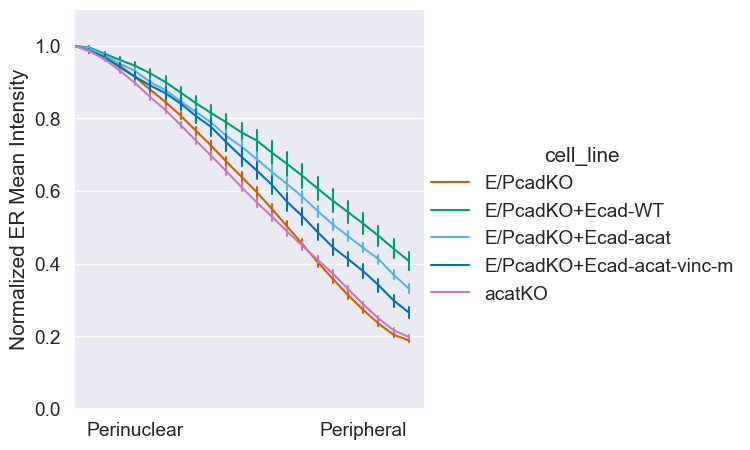

In [18]:
sns.set_theme(style="white")
sns.set(rc = {'figure.figsize':(24,8)})
sns.set(font_scale=1.25)

c = sns.catplot(
    data = foo,
    x = "Slice",
    y = "Normalized Mean",
    hue = "cell_line",
    errorbar = "se", 
    kind="point",
    fillstyle="none",
    #alpha=0.7,
    marker=None,
    #linestyle="dashed",
    palette=palette,
    linewidth=1.5,

)
#sns.move_legend(c, "lower left", 
                #bbox_to_anchor=(.5, 1),
#                title=None)
c.set(xlim=(1, 24), 
      #xticks=[0, 4, 8, 12, 16, 20, 24])
       xticks=[5, 20],
     )
#c.set_xticklabels([0, 4, 8, 12, 16, 20, 24])
c.set_xticklabels(["Perinuclear", "Peripheral"])

#c.ax.legend(loc=1)
#plt.legend(title = "Cell line", 
#           loc = "lower left",
#          frameon=False)
plt.ylabel("Normalized ER Mean Intensity")
#plt.xlabel("Relative radial position")
plt.xlabel("")
plt.xlim(1,24)
plt.ylim(0, 1.1)

plt.savefig(output_csv_dir + "/plot_lineplot-with-markers.png", bbox_inches = "tight", dpi= 300)
plt.savefig(output_csv_dir + "/plot_lineplot-with-markers.pdf", bbox_inches = "tight", dpi= 300)


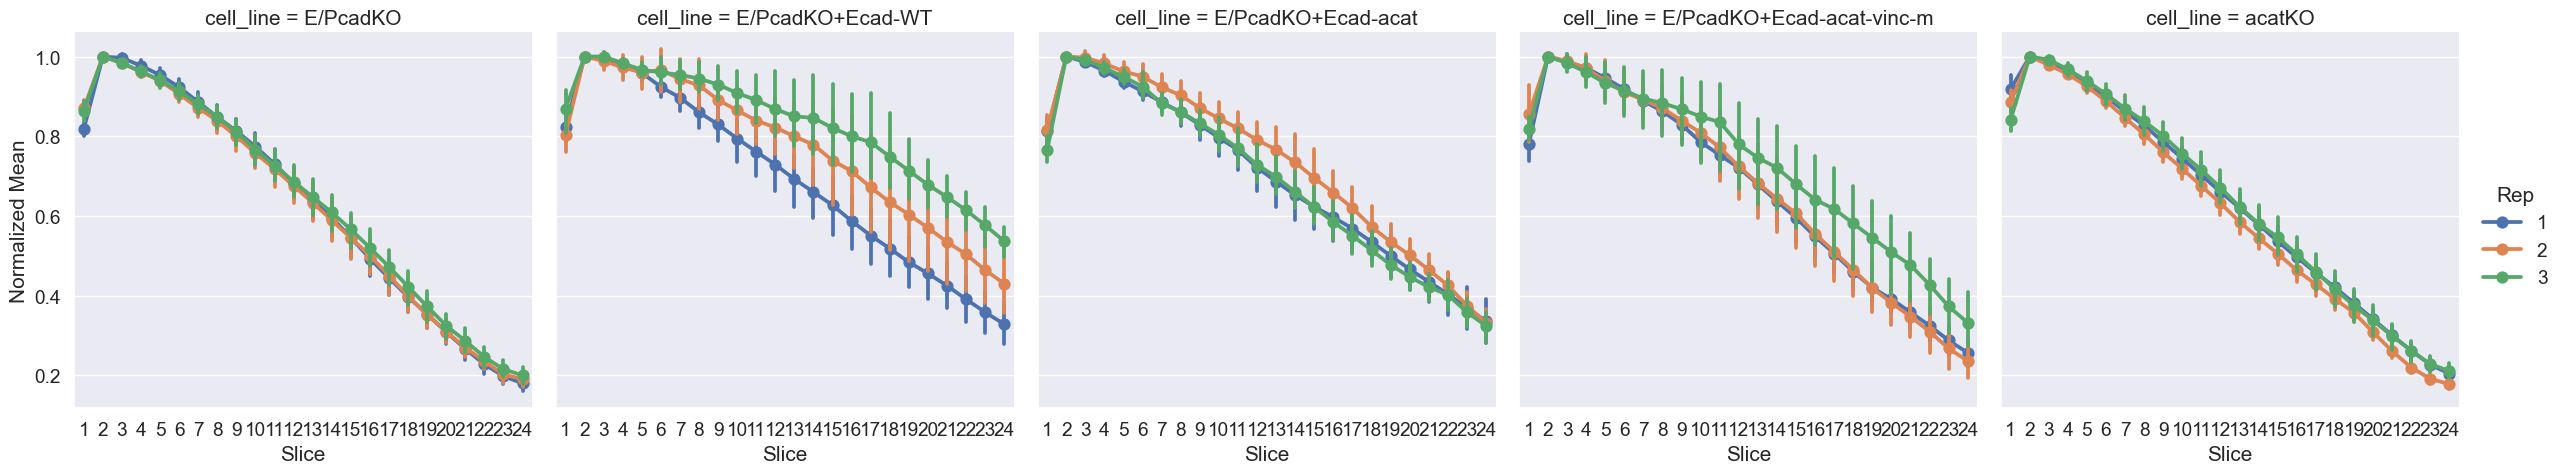

In [19]:
sharp = sns.catplot(foo,
                    x = "Slice",
                    y = "Normalized Mean",
                    hue = "Rep",
                    col = "cell_line",
                    kind = "point",
                    #row = "Rep"
                   )

sharp = sns.catplot(df_ER,
                    x = "Slice",
                    y = "Mean",
                    hue = "Rep",
                    col = "cell_line",
                    kind = "point",
                   )

df_WGA = df.loc[df["channel_name"] == "WGA"]

sharp = sns.catplot(df_WGA,
                    x = "Slice",
                    y = "Mean",
                    hue = "Rep",
                    col = "cell_line",
                    kind = "point",
                    #row = "Rep"
                   )

In [ ]:
#df_ER.groupby(["cell_line", "cell", "image"])[["Mean"]].nth(1)

In [21]:
non_nuclear_ER_rings = df_ER.groupby(["cell_line", "cell", "image", "Rep"])[["Mean"]].tail(23)
non_nuclear_ER_rings

,Mean
1,366.329
2,364.398
3,363.471
4,356.142
5,349.071
...,...
19,320.524
20,276.525
21,244.591
22,198.047


In [23]:
nuclear_ER_rings = df_ER.groupby(["cell_line", "cell", "image", "Rep"])[["Mean"]].nth(1)
nuclear_ER_rings


,Mean
1,366.329
1,321.487
1,319.730
1,411.266
1,237.794
...,...
1,485.277
1,419.887
1,355.474
1,715.771


In [36]:
non_nuclear_ER_rings = df_ER.loc[(df_ER["Slice"] > 1)]
non_nuclear_ER_rings

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
1,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,7.275,366.329,2665.210,630819.0,2,001,1,ER,acatKO,001,1
2,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,6.460,364.398,2354.018,557164.0,3,001,1,ER,acatKO,001,1
3,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,6.557,363.471,2383.352,564107.0,4,001,1,ER,acatKO,001,1
4,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,6.975,356.142,2484.262,587991.0,5,001,1,ER,acatKO,001,1
5,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,7.297,349.071,2547.024,602846.0,6,001,1,ER,acatKO,001,1
...,...,...,...,...,...,...,...,...,...,...,...,...
19,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,42.537,320.524,13634.240,3227039.0,20,005,1,ER,E/PcadKO,010,1
20,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,44.553,276.525,12319.902,2915953.0,21,005,1,ER,E/PcadKO,010,1
21,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,46.745,244.591,11433.514,2706157.0,22,005,1,ER,E/PcadKO,010,1
22,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,49.627,198.047,9828.470,2326265.0,23,005,1,ER,E/PcadKO,010,1


In [25]:
df_ER.loc[(df_ER["Slice"] == 1)]

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
0,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,100.133,338.752,33920.080,8028421.0,1,001,1,ER,acatKO,001,1
0,acatKO+ER-StayGold_ER+WGA_001_R1_cell-002.tif_...,100.331,245.345,24615.679,5826196.0,1,002,1,ER,acatKO,001,1
0,acatKO+ER-StayGold_ER+WGA_001_R1_cell-003.tif_...,109.989,343.918,37827.378,8953225.0,1,003,1,ER,acatKO,001,1
0,acatKO+ER-StayGold_ER+WGA_001_R1_cell-004.tif_...,120.438,370.405,44610.755,10558758.0,1,004,1,ER,acatKO,001,1
0,acatKO+ER-StayGold_ER+WGA_001_R1_cell-005.tif_...,99.613,207.538,20673.429,4893119.0,1,005,1,ER,acatKO,001,1
...,...,...,...,...,...,...,...,...,...,...,...,...
0,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-001.tif...,250.027,401.877,100480.155,23782284.0,1,001,1,ER,E/PcadKO,010,1
0,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-002.tif...,148.255,327.392,48537.639,11488198.0,1,002,1,ER,E/PcadKO,010,1
0,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-003.tif...,167.965,316.342,53134.266,12576157.0,1,003,1,ER,E/PcadKO,010,1
0,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-004.tif...,166.782,643.928,107395.454,25419041.0,1,004,1,ER,E/PcadKO,010,1


In [26]:
#Each ring is divided by nuclear ring 
scaled_non_nuclear_ER_rings = non_nuclear_ER_rings / df_ER.loc[(df_ER["Slice"] == 1)]
scaled_non_nuclear_ER_rings

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
foo = df_ER.loc[(df_ER["Slice"] > 1) & (df_ER["Slice"] < 24)]
foo

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
1,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,7.275,366.329,2665.210,630819.0,2,001,1,ER,acatKO,001,1
2,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,6.460,364.398,2354.018,557164.0,3,001,1,ER,acatKO,001,1
3,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,6.557,363.471,2383.352,564107.0,4,001,1,ER,acatKO,001,1
4,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,6.975,356.142,2484.262,587991.0,5,001,1,ER,acatKO,001,1
5,acatKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_...,7.297,349.071,2547.024,602846.0,6,001,1,ER,acatKO,001,1
...,...,...,...,...,...,...,...,...,...,...,...,...
18,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,39.795,376.016,14963.654,3541693.0,19,005,1,ER,E/PcadKO,010,1
19,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,42.537,320.524,13634.240,3227039.0,20,005,1,ER,E/PcadKO,010,1
20,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,44.553,276.525,12319.902,2915953.0,21,005,1,ER,E/PcadKO,010,1
21,EPcadKO+ER-StayGold_ER+WGA_010_R1_cell-005.tif...,46.745,244.591,11433.514,2706157.0,22,005,1,ER,E/PcadKO,010,1


In [28]:
#inner ring is slice 2 to slice 23
inner = foo[["cell_line", "Mean"]].groupby("cell_line").mean()
inner

,Mean
cell_line,
E/PcadKO,375.164752
E/PcadKO+Ecad-WT,247.469383
E/PcadKO+Ecad-acat,272.237518
E/PcadKO+Ecad-acat-vinc-m,250.621536
acatKO,224.953223


In [29]:
#inner ring for each cell line, each replicate
inner_by_rep = foo[["cell_line", "Mean", "Rep"]].groupby(["cell_line", "Rep"]).mean()
inner_by_rep

Mean
cell_line                 Rep            
E/PcadKO                  1    392.330737
                          2    325.069558
                          3    418.038768
E/PcadKO+Ecad-WT          1    250.410260
                          2    244.986439
                          3    244.779987
E/PcadKO+Ecad-acat        1    288.916010
                          2    238.068747
                          3    304.032432
E/PcadKO+Ecad-acat-vinc-m 1    240.114867
                          2    226.370777
                          3    313.803917
acatKO                    1    204.757431
                          2    207.718840
                          3    289.227170

In [37]:
#Get mean of 2nd ring or the perinuclear ring for each rep (Sonam)

perinuclear_by_rep = df_ER.loc[(df_ER["Slice"] == 2)][["cell_line", "Mean", "Rep"]].groupby(["cell_line", "Rep"]).mean()
perinuclear_by_rep
perinuclear_by_rep.to_csv("perinuclear-by-rep.csv", index=False)


In [31]:
# Perinuclear ER for each cell in each image, rep, cell line
perinuclear_by_cell = df_ER.loc[(df_ER["Slice"] == 2)][["cell_line", "Rep", "image", "cell", "Mean"]]
perinuclear_by_cell
perinuclear_by_cell.to_csv("perinuclear-by-cell.csv", index=False)

In [38]:
# Outer ER for each rep, each cell line
outer_by_rep = df_ER.loc[(df_ER["Slice"] == 24)][["cell_line", "Mean", "Rep"]].groupby(["cell_line", "Rep"]).mean()
outer_by_rep
outer_by_rep.to_csv("outer-by-rep.csv", index=False)

In [ ]:
# Outer ER for each cell, each image, rep, cell line

outer_by_cell = df_ER.loc[(df_ER["Slice"] == 24)][["cell_line", "Rep", "image", "cell", "Mean"]]
outer_by_cell
outer_by_cell.to_csv("outer-by-cell.csv", index=False)

,cell_line,Rep,image,cell,Mean
23,acatKO,1,001,001,79.580
23,acatKO,1,001,002,84.680
23,acatKO,1,001,003,64.550
23,acatKO,1,001,004,86.726
23,acatKO,1,001,005,51.051
...,...,...,...,...,...
23,E/PcadKO,1,010,001,75.397
23,E/PcadKO,1,010,002,106.524
23,E/PcadKO,1,010,003,98.337
23,E/PcadKO,1,010,004,116.281


In [ ]:
# Outer ER to perinuclear ER in each rep
# The suffixes are added to the 'Mean' values from both data frames 
merged_df_rep = pd.merge(outer_by_rep, perinuclear_by_rep, on=["cell_line", "Rep"], suffixes=("_outer", "_perinuclear"))

# Perform element-wise division of the 'Mean' values from 'outer' and 'perinuclear' dataframe
merged_df_rep["Mean_ratio"] = merged_df_rep["Mean_outer"] / merged_df_rep["Mean_perinuclear"]

# Sort the merged DataFrame by 'cell_line' and 'Rep'
merged_df_rep_sorted = merged_df_rep.sort_values(by=["cell_line", "Rep"])

print(merged_df_rep_sorted)
merged_df_rep_sorted.to_csv("outer-to-perinuclear-by-rep.csv", index=False)


                               Mean_outer  Mean_perinuclear  Mean_ratio
cell_line                 Rep                                          
E/PcadKO                  1    106.077393        604.233607    0.175557
                          2     95.137200        512.533800    0.185621
                          3    123.827056        653.970333    0.189347
E/PcadKO+Ecad-WT          1    114.947929        353.233429    0.325416
                          2    135.697667        312.134889    0.434740
                          3    155.919000        291.350000    0.535160
E/PcadKO+Ecad-acat        1    136.026214        406.203714    0.334872
                          2    105.501056        316.389444    0.333453
                          3    136.663833        432.146500    0.316244
E/PcadKO+Ecad-acat-vinc-m 1     92.795462        354.507615    0.261759
                          2     76.281100        341.388400    0.223444
                          3    141.385333        428.133000    0

In [44]:
# Outer ER by perinuclear ER, grouped by each cell, each image, replicate, cell line
# Extract the relevant data frames
outer_by_cell = df_ER.loc[(df_ER["Slice"] == 24)][["cell_line", "Rep", "image", "cell", "Mean"]]
perinuclear_by_cell = df_ER.loc[(df_ER["Slice"] == 2)][["cell_line", "Rep", "image", "cell", "Mean"]]

# Merge on 'cell_line', 'cell', 'image', and 'Rep'
merged_df_by_cell = pd.merge(outer_by_cell, perinuclear_by_cell, on=["cell_line", "Rep", "image", "cell"], suffixes=("_outer", "_perinuclear"))

# Perform element-wise division of the 'Mean' values from 'outer' and 'perinuclear' dataframe
merged_df_by_cell["Mean_ratio"] = merged_df_by_cell["Mean_outer"] / merged_df_by_cell["Mean_perinuclear"]

merged_df_by_cell
merged_df_by_cell.to_csv("outer-to-perinuclear-by-cell.csv", index=False)

In [ ]:
df.to_csv(output_csv_dir + "2025-05-08_merged-results.csv", index=False)